In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import sys
from scipy import stats
from scipy.stats import norm

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/')
from estimate_bayesian_fdr import *
from differential_splicing import *

In [17]:
# Main path set up
main_path="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/0205"

# List the directories in the main path
dirs = os.listdir(main_path)
# Which dirs have "NoCellType_Random" in them 
dirs = [d for d in dirs if "NoCellType_Random" in d]

print(dirs)

['analysis_20250205_111836_PropNeg_0.9_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_500_LearnedConc_Inits_2_NoCellType_Random_71', 'analysis_20250205_111320_PropNeg_0.5_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_2_NoCellType_Random_48', 'analysis_20250205_111849_PropNeg_0.9_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_2_NoCellType_Random_93', 'analysis_20250205_111320_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_500_LearnedConc_Inits_2_NoCellType_Random_81', 'analysis_20250205_111320_PropNeg_0.1_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_500_LearnedConc_Inits_2_NoCellType_Random_86', 'analysis_20250205_111822_PropNeg_0.1_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_2_NoCellType_Random_62', 'analysis_20250205_111839_PropNeg_0.9_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_LearnedConc_Inits_2_NoCellType_Random_34', 'analysis_20250205_111810_PropNeg_0.1_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_50

In [18]:
# Choose which simulation directory to analyze 
dir_analyze=dirs[1]
print(dir_analyze)

# Set up the path to the simulation directory
sim_dir=os.path.join(main_path,dir_analyze)

# Print the names of the files in the simulation directory
files = os.listdir(sim_dir)
print(files)

analysis_20250205_111320_PropNeg_0.5_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_2_NoCellType_Random_48
['clustermap.png', 'losses.png', 'assignment_correlations.png', 'est_deltapsi_vs_difference.png', 'pi_barplot.png', 'nmf_clustermap.png', 'nmf_umap.png.pdf', 'ALBF_scores.csv', 'pi_df.csv', 'albf_vs_difference.png', 'random_init_31291_loss_curve.png', 'random_init_40011_loss_curve.png', 'cell_type_psi_df.csv', 'final_results.csv', 'ALBF_report.txt', 'umap.png.pdf', 'roc_curve.png', 'est_deltapsi_vs_difference.pdf', 'parameters.json', 'precision_recall_curve.png', 'analysis_report.txt', 'precision_recall_curve.pdf', 'ALBF_score_distribution.png']


In [19]:
pis = pd.read_csv(os.path.join(sim_dir, "pi_df.csv"))
# Sort by Factor 
pis = pis.sort_values(by=['Factor'])
pis = pis["pi"].values
pis

array([0.4859913, 0.5140088])

In [20]:
# Original PSI_df from simulation
PSI_df = pd.read_csv(os.path.join(sim_dir, "cell_type_psi_df.csv"))

In [21]:
PSI_df.sample_label.value_counts()

sample_label
positive    7947
negative    7947
Name: count, dtype: int64

In [22]:
# let's load the final_results.csv file 
albf_scores = pd.read_csv(os.path.join(sim_dir, "ALBF_scores.csv"))
# rename the first two columns to be sim_psi_1 and sim_psi_2
albf_scores = albf_scores.rename(columns={"0": "latent_psi_1", "1": "latent_psi_2"})
albf_scores.head()

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,mu_0,loc_0,mu_1,loc_1
0,0.191184,0.470291,0,16.574566,0.247821,positive,35178,1,0.279107,1,-1.439482,0.016650,-0.119532,0.009438
1,0.608012,0.054451,1,51.207916,0.495643,positive,35178,1,0.553561,1,0.440523,0.011518,-2.854859,0.042428
2,0.191234,0.465935,2,18.045120,0.247821,positive,35178,1,0.274701,1,-1.440932,0.012852,-0.126714,0.011008
3,0.243605,0.063282,3,6.264294,0.160126,positive,37286,1,0.180323,1,-1.133175,0.030077,-2.701408,0.069792
4,0.515543,0.875289,4,12.901628,0.320252,positive,37286,1,0.359746,1,0.054278,0.027260,1.942491,0.042257


In [23]:
# How many ALBF values less than 1 
print("Number of ALBF values less than 1: ", len(albf_scores[albf_scores["ALBF"] < 1]))
# How many ALBF values greater than 1
print("Number of ALBF values greater than 1: ", len(albf_scores[albf_scores["ALBF"] > 1]))
# How many ALBF values less than 0 
print("Number of ALBF values less than 0: ", len(albf_scores[albf_scores["ALBF"] < 0]))

Number of ALBF values less than 1:  8492
Number of ALBF values greater than 1:  7402
Number of ALBF values less than 0:  4


In [24]:
albf_scores.sort_values(by=["true_label", "ALBF"], ascending=[True, False], inplace=True)
albf_scores

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,mu_0,loc_0,mu_1,loc_1
4161,9.547213e-01,5.332432e-02,4161,37.138950,0.000000,negative,50891,0,0.901397,1,3.022857,0.124615,-2.880230,0.109348
11050,7.516123e-01,9.967675e-01,11050,36.214127,0.000000,negative,19721,0,0.245155,1,1.119806,0.088133,5.727111,0.057479
10839,4.311219e-09,2.562868e-01,10839,35.483680,0.000000,negative,19652,0,0.256287,1,-30.465687,5.844941,-1.113181,0.157932
13577,6.000638e-01,7.469519e-12,13577,32.211662,0.000000,negative,24562,0,0.600064,1,0.474927,0.063716,-26.868744,6.052905
10106,9.527208e-01,5.093270e-02,10106,30.890678,0.000000,negative,11924,0,0.901788,1,3.022857,0.119788,-3.093090,0.184624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,1.971337e-01,1.980798e-01,2187,0.000362,0.000649,positive,43376,1,0.000946,0,-1.408680,0.024324,-1.400347,0.024285
11834,2.896857e-01,2.912937e-01,11834,0.000304,0.013643,positive,22481,1,0.001608,0,-0.900176,0.044256,-0.890542,0.043159
15831,2.144673e-01,2.145673e-01,15831,0.000198,0.001820,positive,60770,1,0.000100,0,-1.298990,0.006322,-1.296246,0.006490
11257,5.302973e-01,5.216780e-01,11257,0.000167,0.018459,positive,16473,1,0.008619,0,0.123669,0.048750,0.131362,0.048029


In [25]:
# get range of ALBF scores
albf_scores["ALBF"].min(), albf_scores["ALBF"].max()

(-3.0517578e-05, 1396.4081)

In [26]:
em = EMDifferentialSplicing(albf_scores["ALBF"], initial_p=0.1, max_iter=200)
results = em.fit()
threshold = 0.95 

Initial Statistics:
Original ALBF range: [-0.00, 1396.41]
b_j range: [0.5000, 1.0000]

Iteration 1:
p: 0.493293
log likelihood: -7198.951400
q_s1 range: [0.099997, 1.000000]

Iteration 2:
p: 0.729089
log likelihood: -6183.097678
q_s1 range: [0.493285, 1.000000]

Iteration 3:
p: 0.857236
log likelihood: -5974.916873
q_s1 range: [0.729083, 1.000000]

Iteration 4:
p: 0.900000
log likelihood: -5890.906174
q_s1 range: [0.857233, 1.000000]

Iteration 5:
p: 0.900000
log likelihood: -5865.807852
q_s1 range: [0.899997, 1.000000]

Iteration 6:
p: 0.900000
log likelihood: -5865.807852
q_s1 range: [0.899997, 1.000000]

Converged!


In [27]:
albf_scores["posterior_probs"] = results["posterior_probs"]
threshold = 0.95 # for 5% FDR 

albf_scores["significant"] = False 
albf_scores["significant"] = albf_scores["posterior_probs"] >= threshold
albf_scores["significant"].value_counts()

significant
False    8391
True     7503
Name: count, dtype: int64

In [38]:
# how many positives are significant
tp = albf_scores[(albf_scores["true_label"] == "positive") & (albf_scores["significant"])].shape[0]
# how many negatives are significant
fp = albf_scores[(albf_scores["true_label"] == "negative") & (albf_scores["significant"])].shape[0]
# how many positives are not significant
fn = albf_scores[(albf_scores["true_label"] == "positive") & (~albf_scores["significant"])].shape[0]
# how many negatives are not significant
tn = albf_scores[(albf_scores["true_label"] == "negative") & (~albf_scores["significant"])].shape[0]

# FALSE DISCOVERY RATE
fdr = fp / (fp + tp)
print(f"False Discovery Rate: {fdr:.2f}")

# FALSE NEGATIVE RATE
fnr = fn / (fn + tn)
print(f"False Negative Rate: {fnr:.2f}")

False Discovery Rate: 0.02
False Negative Rate: 0.07


In [39]:
print(tp, fp, fn, tn)

7383 120 564 7827


In [29]:
# reindex the albf_scores using junction_id_index so row index matches 
albf_scores = albf_scores.reset_index(drop=True)

In [40]:
def plot_junc_dists(albf_scores, index_junc, pis):
    mus = torch.tensor(albf_scores[["mu_0", "mu_1"]].iloc[index_junc].values)
    variances = torch.tensor(albf_scores[["loc_0", "loc_1"]].iloc[index_junc].values)
    print(f"The means are: {mus}")
    print(f"The variances are: {variances}")

    # compute combined mean and variance
    combined_mean, combined_variance = compute_combined_parameters(mus, variances, pis)
    print(f"The combined mean is: {combined_mean}")
    print(f"The combined variance is: {combined_variance}")

    # Make a list of original mus plus combined one and variances plus combined one to plot
    mus_list = mus.tolist()
    mus_list.append(combined_mean.item())
    variances_list = variances.tolist()
    variances_list.append(combined_variance.item())

    plot_gaussian(mus_list, variances_list)

In [31]:
# This suggests our calculation might be more sensitive to very small variances than to differences in means.
# So when we evaluate at 0 in logit space, we're essentially asking "how likely is a PSI value of 0.5?"
# We're working in logit space where z = log(ψ/(1-ψ))
# When z = 0, that means log(ψ/(1-ψ)) = 0
# Which means ψ/(1-ψ) = 1
# Which means ψ = 0.5

# We're evaluating likelihood ratio at z=0
# In both cases, z=0 is far from where all the distributions are centered
# When we evaluate Gaussians far from their means, we get extremely small probabilities
# Taking log ratios of these tiny probabilities leads to extreme ALBF values

In [32]:
albf_scores.sort_values("ALBF")

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,mu_0,loc_0,mu_1,loc_1,posterior_probs,significant
7946,0.024665,0.024541,3895,-0.000031,0.000000,negative,50272,0,0.000124,0,-3.685138,0.025116,-3.683833,0.025015,0.899997,False
7945,0.783552,0.784500,4213,-0.000019,0.000000,negative,51525,0,0.000949,0,1.287914,0.014400,1.288010,0.014371,0.899998,False
7944,0.044872,0.047048,2343,-0.000004,0.000000,negative,44551,0,0.002177,0,-3.070721,0.073306,-3.070705,0.074043,0.900000,False
7943,0.387670,0.387517,1866,-0.000001,0.000000,negative,39075,0,0.000153,0,-0.459313,0.012733,-0.459277,0.012725,0.900000,False
7942,0.031040,0.031292,11887,0.000000,0.000000,negative,22292,0,0.000252,0,-3.430364,0.018845,-3.429919,0.018713,0.900000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7951,0.397198,0.000006,14499,893.655000,0.386005,positive,34687,1,0.397192,1,-0.417184,0.003510,-11.959226,0.034611,1.000000,True
7950,0.278185,0.999982,10024,913.333070,0.679500,positive,12651,1,0.721798,1,-0.953499,0.003339,10.952597,0.036370,1.000000,True
7949,0.000031,0.999921,4879,949.460500,0.953304,positive,56597,1,0.999891,1,-10.401560,0.060512,9.455819,0.042736,1.000000,True
7948,0.188299,0.999966,14500,1224.042400,0.772009,positive,34687,1,0.811667,1,-1.458531,0.009549,10.272194,0.018794,1.000000,True


The means are: tensor([ -0.4172, -11.9592], dtype=torch.float64)
The variances are: tensor([0.0035, 0.0346], dtype=torch.float64)
The combined mean is: -1.5353026390075684
The combined variance is: 0.006523105315864086
The means are: [-0.41718408, -11.959226, -1.5353026390075684]
The variances are: [0.0035102197, 0.034611445, 0.006523105315864086]
The mean of the sampled PSI values is: 0.4000958343127886
The mean of the sampled PSI values is: 6.760292545561233e-06
The mean of the sampled PSI values is: 0.1748551976101598


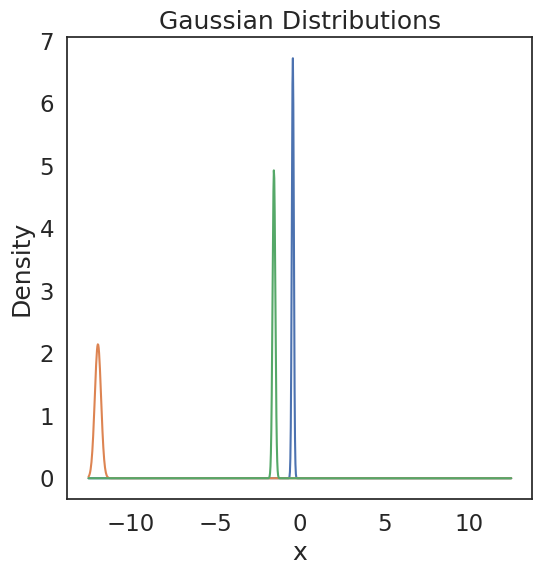

In [35]:
plot_junc_dists(albf_scores, 7951, pis)

<Axes: xlabel='true_label', ylabel='log_ALBF'>

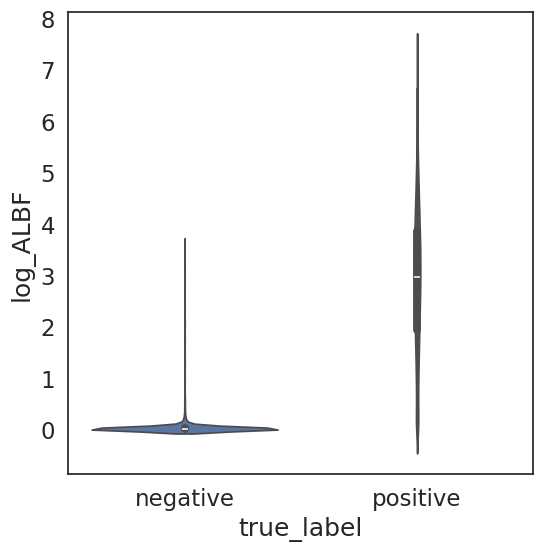

In [36]:
# Compare the ALBF values distribution between positive and negative labels 
plt.figure(figsize=(6, 6))

# Take log1p of ALBF values to make the distribution more interpretable
albf_scores["log_ALBF"] = np.log1p(albf_scores["ALBF"])

# Plot violin plot of ALBF values for positive and negative labels 
sns.violinplot(x="true_label", y="log_ALBF", data=albf_scores)

<Axes: xlabel='significant', ylabel='log_ALBF'>

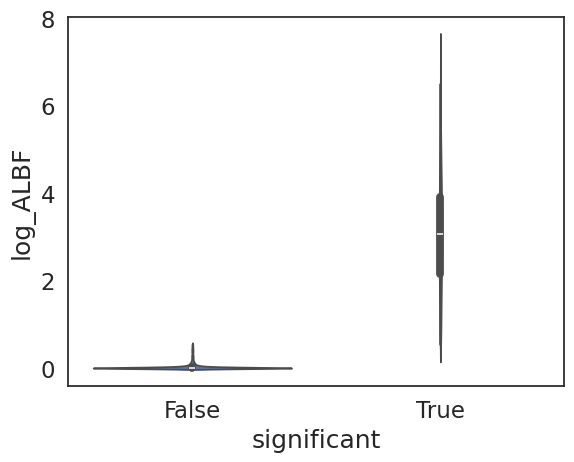

In [37]:
sns.violinplot(x="significant", y="log_ALBF", data=albf_scores)

In [47]:
FDR_ALBF = albf_scores[albf_scores["posterior_probs"] >= 0.95].sort_values(by="ALBF").iloc[0]["ALBF"]
print(f"The ALBF at the 5% FDR threshold is: {FDR_ALBF}")

The ALBF at the 5% FDR threshold is: 0.7493744


Pearson correlation coefficient:  0.5061934768788187
Spearman correlation coefficient:  0.7563391734634451


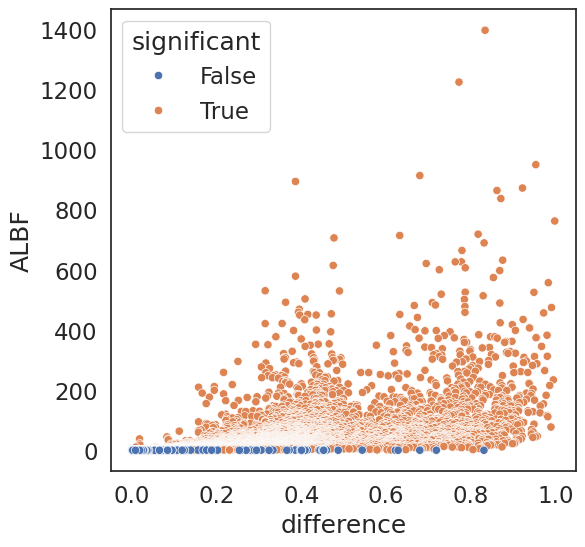

In [48]:
# wtihin positive labels how well did ALBF correlate with simulated difference 
plt.figure(figsize=(6, 6))
sns.scatterplot(data=albf_scores[albf_scores["true_label"] == "positive"], x="difference", y="ALBF", hue="significant")
print("Pearson correlation coefficient: ", albf_scores[albf_scores["true_label"] == "positive"]["difference"].corr(albf_scores[albf_scores["true_label"] == "positive"]["ALBF"]))
print("Spearman correlation coefficient: ", albf_scores[albf_scores["true_label"] == "positive"]["difference"].corr(albf_scores[albf_scores["true_label"] == "positive"]["ALBF"], method="spearman"))

Pearson correlation coefficient:  0.4914805337714686
Spearman correlation coefficient:  0.7621618139407217


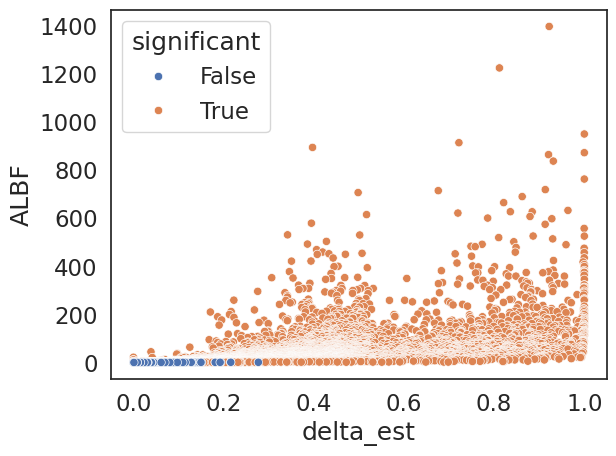

In [49]:
sns.scatterplot(data=albf_scores[albf_scores["true_label"] == "positive"], x="delta_est", y="ALBF", hue="significant")
print("Pearson correlation coefficient: ", albf_scores[albf_scores["true_label"] == "positive"]["delta_est"].corr(albf_scores[albf_scores["true_label"] == "positive"]["ALBF"]))
print("Spearman correlation coefficient: ", albf_scores[albf_scores["true_label"] == "positive"]["delta_est"].corr(albf_scores[albf_scores["true_label"] == "positive"]["ALBF"], method="spearman"))

Pearson correlation coefficient:  0.9736845232333842
Spearman correlation coefficient:  0.9694619023726058


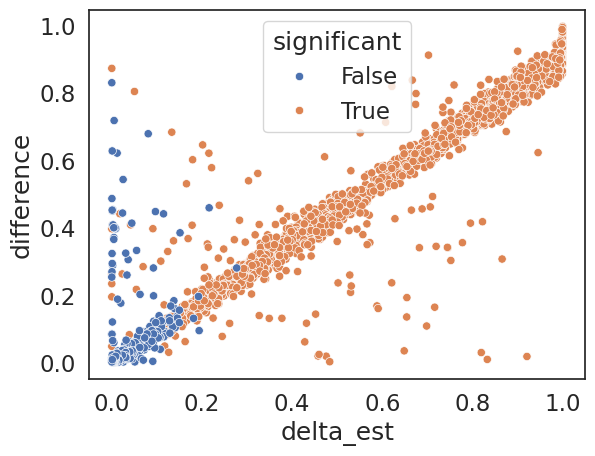

In [50]:
sns.scatterplot(data=albf_scores[albf_scores["true_label"] == "positive"], x="delta_est", y="difference", hue="significant")
# print pearson and spearman correlation coefficients
print("Pearson correlation coefficient: ", albf_scores[albf_scores["true_label"] == "positive"]["delta_est"].corr(albf_scores[albf_scores["true_label"] == "positive"]["difference"]))
print("Spearman correlation coefficient: ", albf_scores[albf_scores["true_label"] == "positive"]["delta_est"].corr(albf_scores[albf_scores["true_label"] == "positive"]["difference"], method="spearman"))

<Axes: xlabel='difference', ylabel='ALBF'>

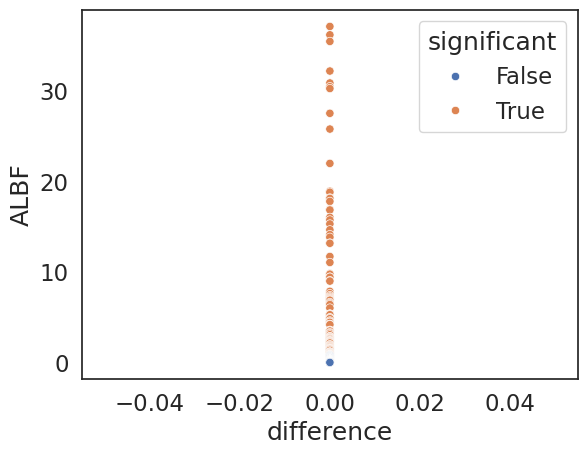

In [51]:
sns.scatterplot(data=albf_scores[albf_scores["true_label"] == "negative"], x="difference", y="ALBF", hue="significant")

In [53]:
# lets get percentile ALBF values of negative labels for calibration analysis of positive labels
percentiles = albf_scores[albf_scores["true_label"] == "negative"]["ALBF"].describe(percentiles=[0.5, 0.6, 0.7, 0.8, 0.85, 0.95, 0.975, 0.99])
# keep just the percentiles we defined 
percentiles = percentiles[["50%", "60%", "70%", "80%", "85%", "95%", "97.5%", "99%"]]

In [54]:
for perc, value in percentiles.items():
    # make a new column for each percentile in albf_scores 
    albf_scores[f"percentile_{perc}"] = False
    # check ALBF values if tehy are greater than the percentile value label them as sig 
    albf_scores[f"significant_{perc}"] = albf_scores["ALBF"] >= value
    print(f"The ALBF value at {perc} percentile is: {value}")

    # calculate the number of significant values, get FDR 
    tp = albf_scores[(albf_scores["true_label"] == "positive") & (albf_scores[f"significant_{perc}"])].shape[0]
    fp = albf_scores[(albf_scores["true_label"] == "negative") & (albf_scores[f"significant_{perc}"])].shape[0]
    
    perc_num = float(perc[:-1]) / 100
    print(f"At {perc} percentile of null distribution, the expected FDR is {1-(perc_num):.2f}")
    print(f"At {perc} percentile of null distribution, number of positives: {tp}, number of negatives: {fp}")
    
    fdr = fp / (fp + tp)
    print(f"At {perc} percentile of null distribution, False Discovery Rate: {fdr:.2f}")
    print(f"-----------------------------------")
    print(f"-----------------------------------")

The ALBF value at 50% percentile is: 0.007980347
At 50% percentile of null distribution, the expected FDR is 0.50
At 50% percentile of null distribution, number of positives: 7905, number of negatives: 3975
At 50% percentile of null distribution, False Discovery Rate: 0.33
-----------------------------------
-----------------------------------
The ALBF value at 60% percentile is: 0.011360740499999997
At 60% percentile of null distribution, the expected FDR is 0.40
At 60% percentile of null distribution, number of positives: 7892, number of negatives: 3179
At 60% percentile of null distribution, False Discovery Rate: 0.29
-----------------------------------
-----------------------------------
The ALBF value at 70% percentile is: 0.0166165352
At 70% percentile of null distribution, the expected FDR is 0.30
At 70% percentile of null distribution, number of positives: 7867, number of negatives: 2384
At 70% percentile of null distribution, False Discovery Rate: 0.23
------------------------

In [57]:
# let;s find some positive labeled junctions that got labelled as not significant by us
albf_scores[(albf_scores["true_label"] == "positive") & (~albf_scores["significant"])].sort_values(by="difference")

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,...,percentile_80%,significant_80%,percentile_85%,significant_85%,percentile_95%,significant_95%,percentile_97.5%,significant_97.5%,percentile_99%,significant_99%
15848,1.661169e-01,0.169734,4400,0.008991,0.000196,positive,51854,1,0.003617,0,...,False,False,False,False,False,False,False,False,False,False
15882,1.632392e-01,0.166896,4398,0.001381,0.000196,positive,51854,1,0.003657,0,...,False,False,False,False,False,False,False,False,False,False
15856,6.702830e-01,0.665694,4399,0.006187,0.000392,positive,51854,1,0.004589,0,...,False,False,False,False,False,False,False,False,False,False
15889,1.971337e-01,0.198080,2187,0.000362,0.000649,positive,43376,1,0.000946,0,...,False,False,False,False,False,False,False,False,False,False
15815,2.006614e-01,0.191620,2189,0.016182,0.000649,positive,43376,1,0.009041,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15669,9.414535e-01,0.953275,13876,0.112429,0.621841,positive,30694,1,0.011822,0,...,False,True,False,True,False,False,False,False,False,False
15881,9.529251e-01,0.953914,5452,0.001450,0.628281,positive,56225,1,0.000989,0,...,False,False,False,False,False,False,False,False,False,False
15683,1.442476e-01,0.063487,8044,0.095994,0.679388,positive,8646,1,0.080761,0,...,False,True,False,True,False,False,False,False,False,False
15798,9.524527e-01,0.947289,7510,0.021042,0.718568,positive,5834,1,0.005163,0,...,False,False,False,False,False,False,False,False,False,False


The means are: tensor([-22.2975, -23.3571], dtype=torch.float64)
The variances are: tensor([7.1266, 6.4278], dtype=torch.float64)
The combined mean is: -22.869434356689453
The combined variance is: 6.749431133270264
The means are: [-22.297527, -23.357138, -22.869434356689453]
The variances are: [7.1266313, 6.4277654, 6.749431133270264]
The mean of the sampled PSI values is: 5.780288324091042e-09
The mean of the sampled PSI values is: 6.104352601154217e-10
The mean of the sampled PSI values is: 3.7687663353345887e-10


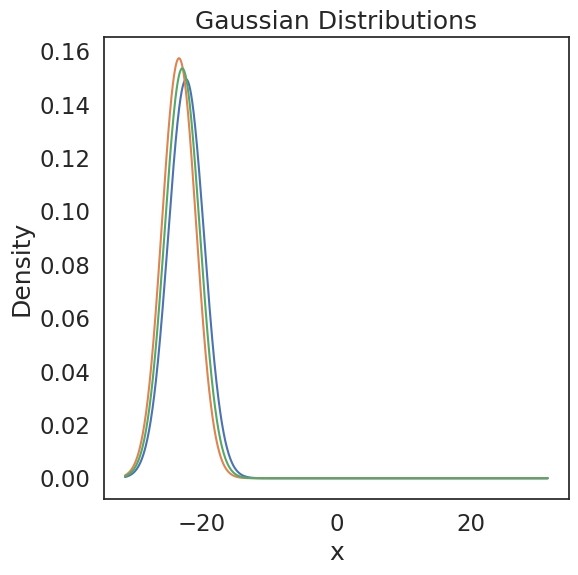

In [59]:
plot_junc_dists(albf_scores, 15796, pis)